In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

import joblib

RANDOM_STATE = 42
TEST_SIZE = 0.2

CRITERION = "gini"
SPLITTER = "best"

MODEL_FILENAME = "decision_tree_model.joblib"
TREE_IMAGE_FILENAME = "pruned_tree.png"

In [2]:
# Decision Tree Classifier on The Iris Dataset
##Objective
""" Build a baseline Decision Tree Classifier, optimise it using cost-somplexity pruning, evaluate the performance, visualise the final tree, and serialise the optimised model.
"""

' Build a baseline Decision Tree Classifier, optimise it using cost-somplexity pruning, evaluate the performance, visualise the final tree, and serialise the optimised model.\n'

In [8]:
#Load and insoect dataset
df = pd.read_csv("iris.csv")
#Preview the dataset
print("First 5 rows:")
print(df.head())

#Dataset Dimensions
print(f"\nDataset Shape: {df.shape}")

#Dataset information
print(f"\nDataset Information:")
df.info()

#Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

#Check class distribution
print("\nClass Distribution:")
print(df.iloc[:, -1].value_counts())

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype:

In [12]:
#Separate the features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

#Verify the split
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

print(f"Training Labels Shape: {y_train.shape}")
print(f"Testing Labels Shape: {y_test.shape}")

#Verify Stratification
print("\nTraining Set Class Distribution")
print(y_train.value_counts())

print("\nTest Set Class Distribution")
print(y_test.value_counts())


Training Features Shape: (120, 4)
Testing Features Shape: (30, 4)
Training Labels Shape: (120,)
Testing Labels Shape: (30,)

Training Set Class Distribution
species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64

Test Set Class Distribution
species
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64


In [13]:
#TRAIN BASELINE DECISION TREE
#Initialise model
baseline_tree = DecisionTreeClassifier(
    criterion=CRITERION,
    random_state=RANDOM_STATE
)

#TRAIN MODEL
baseline_tree.fit(X_train, y_train)

print("BASELINE TREE TRAINED SUCCESSFULLY")

BASELINE TREE TRAINED SUCCESSFULLY


In [14]:
#EVALUATE BASELINE MODEL
y_pred = baseline_tree.predict(X_test)

#ACCURACY
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

#PRECISION, RECALL, F1 (macro = treats all classes equally)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

#Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
#Full Classification Report 
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9333
Precision: 0.9333
Recall: 0.9333
F1 Score: 0.9333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [18]:
#Cost-Complexity Pruning (CCP)

path = baseline_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(f"Number of candidate alphas: {len(ccp_alphas)}")

#Train a tree for each alpha
trees = []
train_scores = []
test_scores = []

for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(
        criterion=CRITERION,
        random_state=RANDOM_STATE,
        ccp_alpha=alpha
    )

    tree.fit(X_train, y_train)

    #Store model
    trees.append(tree)

    #Evaluate models
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

print("Pruning sweep completed.")


Number of candidate alphas: 6
Pruning sweep completed.


In [19]:
#Convert scores to numpy array for easy indexing
test_scores = np.array(test_scores)
train_scores = np.array(train_scores)

#Find index of best test score
best_index = np.argmax(test_scores)

best_alpha = ccp_alphas[best_index]
best_test_score = test_scores[best_index]
best_train_score = train_scores[best_index]

print(f"Best ccp_alpha: {best_alpha:.6f}")
print(f"Best Test accuracy: {best_test_score:.4f}")
print(f"Corresponding Train Accuracy: {best_train_score:.4f}")


Best ccp_alpha: 0.006250
Best Test accuracy: 0.9667
Corresponding Train Accuracy: 0.9917


In [ ]:
plt.figure()

plt.plot(ccp_alphas, train_scores, label="TRAIN ACCURACY")
plt.plot(ccp_alphas, test_scores, label="TEST ACCURACY")

plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs CCP Alpha")
plt.legend()

plt.show()

In [20]:
# TRAIN FINAL PRUNED MODEL
final_tree = DecisionTreeClassifier(
    criterion=CRITERION,
    random_state=RANDOM_STATE,
    ccp_alpha=best_alpha
)

final_tree.fit(X_train, y_train)

print("FINAL PRUNED MODEL TRAINED SUCCESSFULLY")

FINAL PRUNED MODEL TRAINED SUCCESSFULLY


In [21]:
y_final_pred = final_tree.predict(X_test)

#Metrics
final_acc = accuracy_score(y_test, y_final_pred)
final_precision = precision_score(y_test, y_final_pred, average="macro")
final_recall = recall_score(y_test, y_final_pred, average="macro")
final_f1 = f1_score(y_test, y_final_pred, average="macro")

print(f"Final Accuracy: {final_acc:.4f}")
print(f"Final Precision: {final_precision:.4f}")
print(f"Final Recall: {final_recall:.4f}")
print(f"Final F1 Score: {final_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_final_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_final_pred))


Final Accuracy: 0.9667
Final Precision: 0.9697
Final Recall: 0.9667
Final F1 Score: 0.9666

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



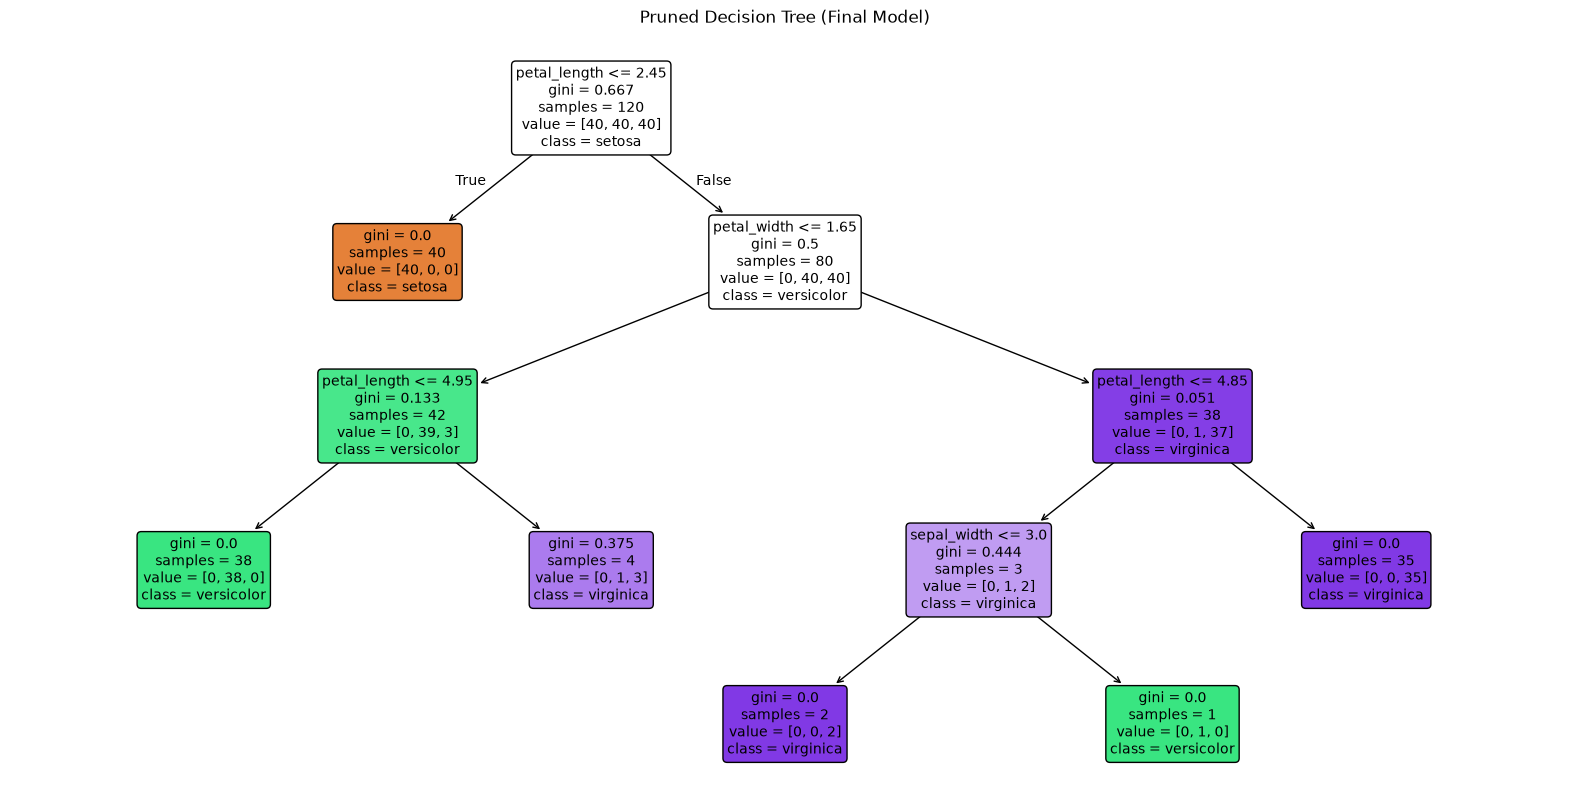

TREE SAVED AS pruned_tree.png


In [22]:
plt.figure(figsize=(20, 10))

plot_tree(
    final_tree,
    feature_names=X.columns,
    class_names=final_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Pruned Decision Tree (Final Model)")
plt.savefig(TREE_IMAGE_FILENAME, dpi=300, bbox_inches="tight")
plt.show()
print(f"TREE SAVED AS {TREE_IMAGE_FILENAME}")

In [23]:
joblib.dump(final_tree, MODEL_FILENAME)
print(f"Model saved successfully as: {MODEL_FILENAME}")

Model saved successfully as: decision_tree_model.joblib


In [24]:
# Load model back
loaded_model = joblib.load(MODEL_FILENAME)

# Test prediction consistency
original_pred = final_tree.predict(X_test)
loaded_pred = loaded_model.predict(X_test)

print("Reload check passed:", (original_pred == loaded_pred).all())

Reload check passed: True
